# display5 — figures and tables for Chapter *Experimentation and Results*

Run the cells in order. Requires a completed `outputs5/` from `run_experiment5.py`.

- Every figure is saved as a PDF into `figures5/` and also shown inline.
- Every table is displayed as a pandas DataFrame; convert to LaTeX later
  (`df.to_latex()` works directly, or use the builders in `functions5.py`).

**Fixed experimental parameters** (set in `run_experiment5.py`, echoed here so
every plot is unambiguous):

| parameter | value |
|---|---|
| $\widehat W_2$ sample size | $N = 10{,}000$ per evaluation, exact network simplex (POT), no entropic regularisation |
| final $\widehat W_2$ | mean of 3 repeats, both samples redrawn each repeat, common random numbers (`eval_seed = 9000 + repeat`) |
| checkpoint $\widehat W_2$ | 1 repeat (curves indicative; final numbers are the 3-repeat ones) |
| training | 50,000 iterations, batch 512, $\kappa(t)=\sigma_t^2$ |
| forward/reverse | $T = 2$ (except the E2 sweep), $\gamma = 10^{-3}$, so $\epsilon = \gamma$; $t_0 = 10^{-3}$ |
| seeds | 3 training seeds per configuration in the main stage |
| score error | $\mathcal E(t)$ by Monte Carlo, 20,000 exact draws from $p_t$, at $t \in \{0.01, 0.05, 0.1, 0.25, 0.5, 1, 2\}$; $\overline{\mathcal E}$ = average over that grid |
| histogram samples | 1,000,000 per stored run (seed 0 only) |
| hyperparameters | grid-searched (Cell 3); $\beta=10^{10}$, $r=10$, $\eta = 5\times10^{-4}\sqrt\lambda$ from Lim & Sabanis (2024) |


In [1]:
# ============================================================
# Cell 1 — setup and data loading
# Loads every .pt in outputs5/, routed by shape:
#   runs   : training runs (have a "config" key)
#   floors : finite-sample floor records
#   other  : grid_summary (all grid rows), best_params5 (selected optima)
# ============================================================
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import functions5 as fct

OUT_DIR = "outputs5"
FIG_DIR = "figures5"
os.makedirs(FIG_DIR, exist_ok=True)

MU = np.array([1.3, 1.3])          # mixture mean / unknown mean mu*
N_W2 = 10_000                      # Wasserstein sample size (all evaluations)
SCORE_TS = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

pd.set_option("display.precision", 4)

runs, floors_raw, other = fct.load_all(OUT_DIR)

floors = {n.replace("floor_", ""): r for n, r in floors_raw.items()}
grid_rows = other.get("grid_summary", [])
best_params = other.get("best_params5", {})

main_runs   = {k: v for k, v in runs.items() if k.startswith("ex")}
tsweep_runs = {k: v for k, v in runs.items() if k.startswith("tsweep")}
depth_runs  = {k: v for k, v in runs.items() if k.startswith("depth")}
print(f"main {len(main_runs)} | tsweep {len(tsweep_runs)} | "
      f"depth {len(depth_runs)}")


def savefig(name):
    """Save the current figure to figures5/<name>.pdf, then show inline."""
    plt.savefig(os.path.join(FIG_DIR, name + ".pdf"), bbox_inches="tight")
    plt.show()


loaded 60 runs, 2 floors, 2 other
main 36 | tsweep 12 | depth 12


## Cell 2 — the finite-sample floor (tab:w2_floor)

$\widehat W_2^{\,\mathrm{floor}}(N)$: distance between two *independent*
$N$-samples of the same target — the resolution limit of the metric. Two
reference rates are shown, anchored at the largest $N$:

- $N^{-1/2}$: the sharp rate in $d=2$ (Ajtai–Komlós–Tusnády / Talagrand,
  $\sqrt{\log N/N}$ up to the log factor) — what the measurement should follow;
- $N^{-1/4}$: the Fournier & Guillin (2015) moment bound — an upper bound only.

The fitted slope is printed; expect it near $-0.5$.

bimodal: fitted slope -0.495   (sharp d=2 rate: -0.5, Fournier-Guillin bound: -0.25)
gaussian: fitted slope -0.428   (sharp d=2 rate: -0.5, Fournier-Guillin bound: -0.25)


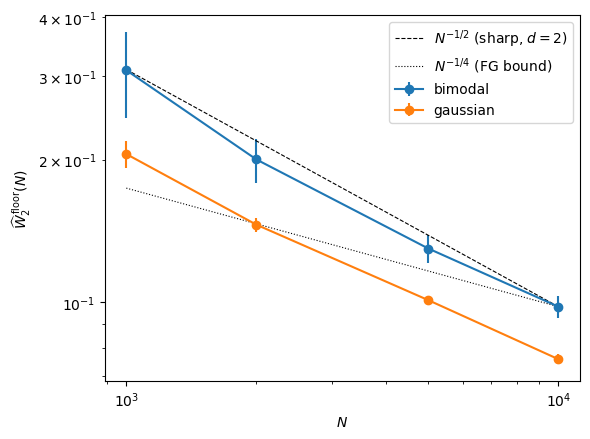

,target,N,floor,sd
0,bimodal,1000,0.3088,0.0638
1,bimodal,2000,0.2002,0.0213
2,bimodal,5000,0.1299,0.0087
3,bimodal,10000,0.0980,0.0052
4,gaussian,1000,0.2056,0.0132
5,gaussian,2000,0.1459,0.0049
6,gaussian,5000,0.1011,0.0023
7,gaussian,10000,0.0759,0.0019


In [2]:
# Parameters: FLOOR_NS = [1000, 2000, 5000, 10000], 3 repeats per N,
# common random numbers (eval_seed = 9000 + repeat), exact solver.
rows = []
for tname, rec in floors.items():
    for N, d_ in sorted(rec["by_N"].items()):
        rows.append(dict(target=tname, N=N, floor=d_["mean"], sd=d_["std"]))
floor_df = pd.DataFrame(rows)

# fitted decay rate per target
for tname in floor_df["target"].unique():
    sub = floor_df[floor_df["target"] == tname]
    slope = np.polyfit(np.log(sub["N"]), np.log(sub["floor"]), 1)[0]
    print(f"{tname}: fitted slope {slope:.3f}   "
          f"(sharp d=2 rate: -0.5, Fournier-Guillin bound: -0.25)")

plt.figure(figsize=(6, 4.5))
for tname, sub in floor_df.groupby("target"):
    plt.errorbar(sub["N"], sub["floor"], yerr=sub["sd"], marker="o",
                 label=tname)
Ns = np.array(sorted(floor_df["N"].unique()))
ref = floor_df[floor_df["N"] == Ns[-1]]["floor"].max()
plt.plot(Ns, ref * (Ns[-1] / Ns) ** 0.5, "k--", lw=0.8,
         label=r"$N^{-1/2}$ (sharp, $d=2$)")
plt.plot(Ns, ref * (Ns[-1] / Ns) ** 0.25, "k:", lw=0.8,
         label=r"$N^{-1/4}$ (FG bound)")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("$N$"); plt.ylabel(r"$\widehat W_2^{\,\mathrm{floor}}(N)$")
plt.legend(); plt.tight_layout()
savefig("w2_floor")

floor_df


## Cell 3 — grid search (tab:gridsearch_results)

Equal tuning budget: $\lambda \in \{10, 1, 0.1, 0.01, 0.001\}$ for all four
optimisers (Lim & Sabanis 2024 §4.2); TheoPouLa additionally
$\varepsilon_b \in \{0.1, 0.01\}$ at its best $\lambda$ (§4.3). Scored by
$\widehat W_2$ at $N=10{,}000$ (2 repeats, CRN) after 20,000 selection
iterations on the bimodal target, two-layer network. Fixed: $\beta = 10^{10}$,
$r = 10$, $\eta = 5\times10^{-4}\sqrt\lambda$.

In [3]:
grid_df = pd.DataFrame(grid_rows)
grid_df = grid_df.sort_values(["optimiser", "w2_mean"],
                              na_position="last").reset_index(drop=True)
print("selected optima:", best_params)
grid_df


selected optima: {'adam': {'lam': 0.001, 'eps_b': 0.1}, 'sgld': {'lam': 0.01, 'eps_b': 0.1}, 'tusla': {'lam': 1.0, 'eps_b': 0.1}, 'theopoula': {'lam': 0.01, 'eps_b': 0.1}}


,optimiser,lam,eps_b,beta,r,w2_mean,w2_std,diverged
0,adam,0.001,NaN,1.0000e+10,10.0,0.1536,0.0070,False
1,adam,0.010,NaN,1.0000e+10,10.0,0.2555,0.0090,False
2,adam,0.100,NaN,1.0000e+10,10.0,1.0089,0.0154,False
3,adam,10.000,NaN,1.0000e+10,10.0,6.3129,0.0211,False
4,adam,1.000,NaN,1.0000e+10,10.0,14.2383,0.0528,False
5,sgld,0.010,NaN,1.0000e+10,10.0,0.1492,0.0044,False
6,sgld,0.100,NaN,1.0000e+10,10.0,0.1559,0.0049,False
7,sgld,0.001,NaN,1.0000e+10,10.0,0.5310,0.0042,False
8,sgld,10.000,NaN,1.0000e+10,10.0,NaN,NaN,True
9,sgld,1.000,NaN,1.0000e+10,10.0,NaN,NaN,True


## Cell 4 — main results (E3, tab:w2_results)

One row per (example, optimiser): $\widehat W_2$ mean and s.d. **across the 3
training seeds** (each seed's value is itself a 3-repeat CRN mean at
$N=10{,}000$ after 50,000 iterations), aggregate score error
$\overline{\mathcal E}$, mode balance (meaningful for ex3 only; 0.5 is
perfect), divergence count, and the floor at the same $N$.

In [4]:
from collections import defaultdict

by_group = defaultdict(list)
for tag, rec in main_runs.items():
    c = rec["config"]
    by_group[(c["example"], c["optimiser"])].append(rec)

rows = []
for (ex, opt), recs in sorted(by_group.items()):
    ok = [r_ for r_ in recs if not r_["diverged"] and "w2_mean" in r_]
    tname = recs[0]["config"]["target"]
    row = dict(example=ex, optimiser=opt, target=tname,
               floor=floors[tname]["mean"],
               diverged=f"{sum(r_['diverged'] for r_ in recs)}/{len(recs)}")
    if ok:
        row.update(
            W2=np.mean([r_["w2_mean"] for r_ in ok]),
            seed_sd=np.std([r_["w2_mean"] for r_ in ok]),
            Ebar=np.mean([r_["score_error_agg"] for r_ in ok]),
            balance=(np.mean([r_["mode_balance"] for r_ in ok])
                     if tname == "bimodal" else np.nan))
    rows.append(row)
main_df = pd.DataFrame(rows)[
    ["example", "optimiser", "W2", "seed_sd", "floor", "Ebar", "balance",
     "diverged"]]
main_df


,example,optimiser,W2,seed_sd,floor,Ebar,balance,diverged
0,ex1,adam,0.0889,0.0023,0.0759,3.4150e-05,NaN,0/3
1,ex1,sgld,0.0860,0.0002,0.0759,8.0676e-06,NaN,0/3
2,ex1,theopoula,0.0876,0.0006,0.0759,8.9433e-06,NaN,0/3
3,ex1,tusla,0.5701,0.0005,0.0759,1.5738e-01,NaN,0/3
4,ex2,adam,0.1068,0.0038,0.0759,1.8373e-03,NaN,0/3
5,ex2,sgld,0.0980,0.0015,0.0759,4.3603e-03,NaN,0/3
6,ex2,theopoula,0.0961,0.0037,0.0759,3.4144e-03,NaN,0/3
7,ex2,tusla,2.0624,0.0006,0.0759,6.8229e-01,NaN,0/3
8,ex3,adam,0.1230,0.0120,0.0980,4.3799e-03,0.5065,0/3
9,ex3,sgld,0.1185,0.0063,0.0980,1.2945e-02,0.4967,0/3


## Cell 5 — E1: convergence against iterations (fig:e1_iterations)

For one example and one seed: $\widehat W_2$ (left, against the floor) and
$\overline{\mathcal E}$ (right) at checkpoints {1k, 2k, 5k, 10k, 20k, 50k},
all from ONE continuous run per optimiser (checkpoint evaluation happens
inside the training loop, so Adam's moments are never reset). Checkpoint W2 is
a single repeat, so treat small differences as indicative. The two panels can
disagree: mode-weight fluctuations of ~0.5% move W2 by a factor of ~2 on the
bimodal target while the score error is unchanged.

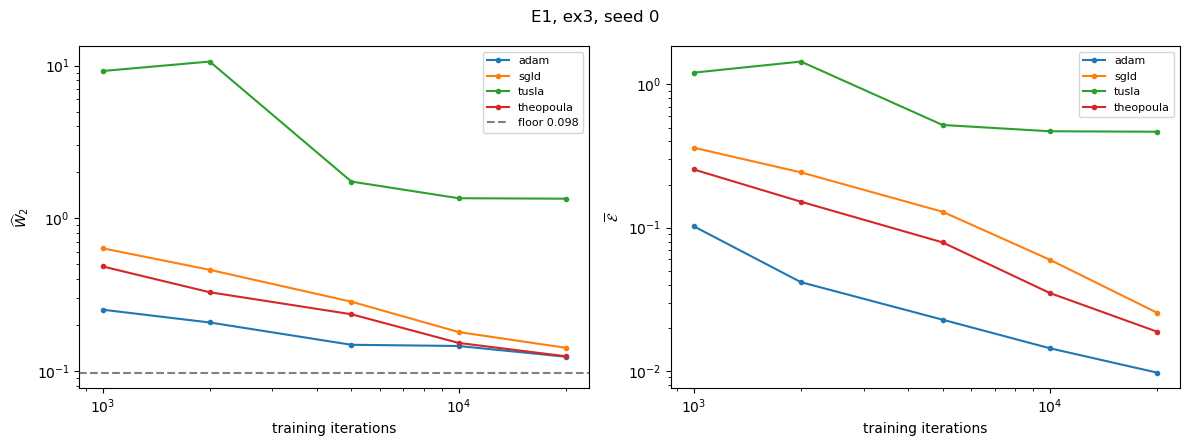

In [5]:
EXAMPLE = "ex3"          # <-- one of "ex1", "ex2", "ex3"
SEED = 0                 # <-- training seed whose curve is shown

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for opt in ["adam", "sgld", "tusla", "theopoula"]:
    recs = [r_ for r_ in main_runs.values()
            if r_["config"]["example"] == EXAMPLE
            and r_["config"]["optimiser"] == opt
            and r_["config"]["seed"] == SEED]
    if not recs:
        continue
    ce = recs[0]["checkpoint_evals"]
    its = sorted(ce)
    axes[0].plot(its, [ce[i]["w2_mean"] for i in its], marker="o", ms=3,
                 label=opt)
    axes[1].plot(its, [ce[i]["score_error_agg"] for i in its], marker="o",
                 ms=3, label=opt)

tname = {"ex1": "gaussian", "ex2": "gaussian", "ex3": "bimodal"}[EXAMPLE]
axes[0].axhline(floors[tname]["mean"], color="grey", ls="--",
                label=f"floor {floors[tname]['mean']:.3f}")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("training iterations"); axes[0].set_ylabel(r"$\widehat W_2$")
axes[0].legend(fontsize=8)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("training iterations")
axes[1].set_ylabel(r"$\overline{\mathcal{E}}$")
axes[1].legend(fontsize=8)
plt.suptitle(f"E1, {EXAMPLE}, seed {SEED}")
plt.tight_layout()
savefig(f"e1_iterations_{EXAMPLE}")


## Cell 6 — E1: score error resolved in $t$ (fig:e1_score_error_by_t)

$\mathcal E(t)$ at each checkpoint, for one (example, optimiser, seed).
Unweighted, measured under $p_t$ with 20,000 exact draws per $t$. This is the
quantity the $\sigma_t^2$-weighted training loss under-penalises at small $t$.
Tests Remark rem:representability: is the residual error concentrated at small
$t$, where the affine component of the target score dominates?

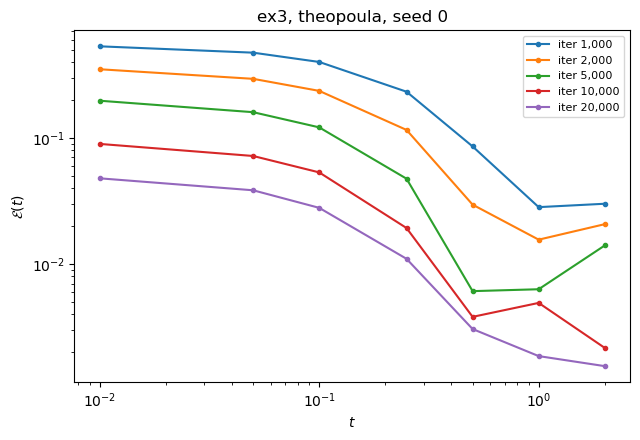

In [6]:
EXAMPLE_SE = "ex3"       # <-- example
OPT_SE = "theopoula"     # <-- optimiser
SEED_SE = 0              # <-- seed

recs = [r_ for r_ in main_runs.values()
        if r_["config"]["example"] == EXAMPLE_SE
        and r_["config"]["optimiser"] == OPT_SE
        and r_["config"]["seed"] == SEED_SE]
if recs:
    ce = recs[0]["checkpoint_evals"]
    plt.figure(figsize=(6.5, 4.5))
    for it in sorted(ce):
        se = ce[it]["score_error"]
        ts = sorted(se)
        plt.plot(ts, [se[t] for t in ts], marker="o", ms=3,
                 label=f"iter {it:,}")
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("$t$"); plt.ylabel(r"$\mathcal{E}(t)$")
    plt.legend(fontsize=8)
    plt.title(f"{EXAMPLE_SE}, {OPT_SE}, seed {SEED_SE}")
    plt.tight_layout()
    savefig(f"e1_score_error_by_t_{EXAMPLE_SE}_{OPT_SE}")


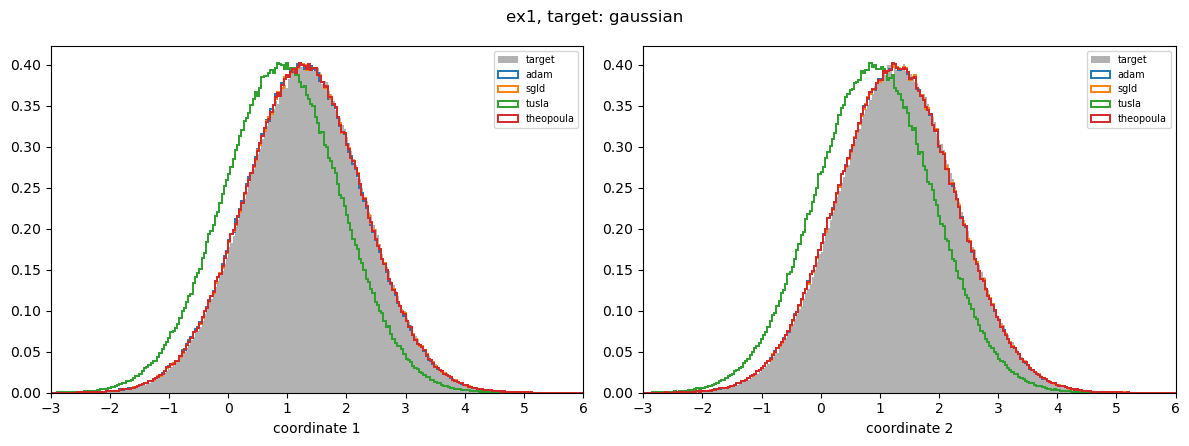

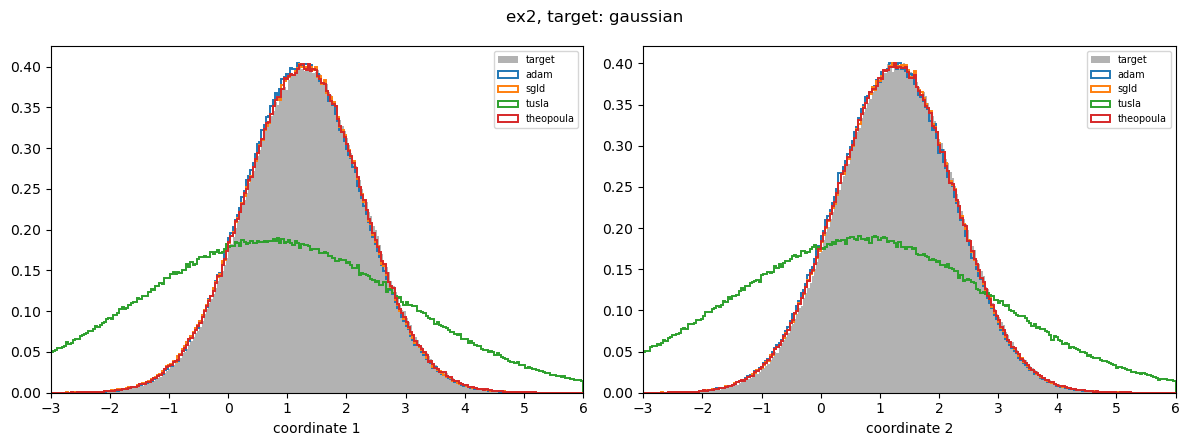

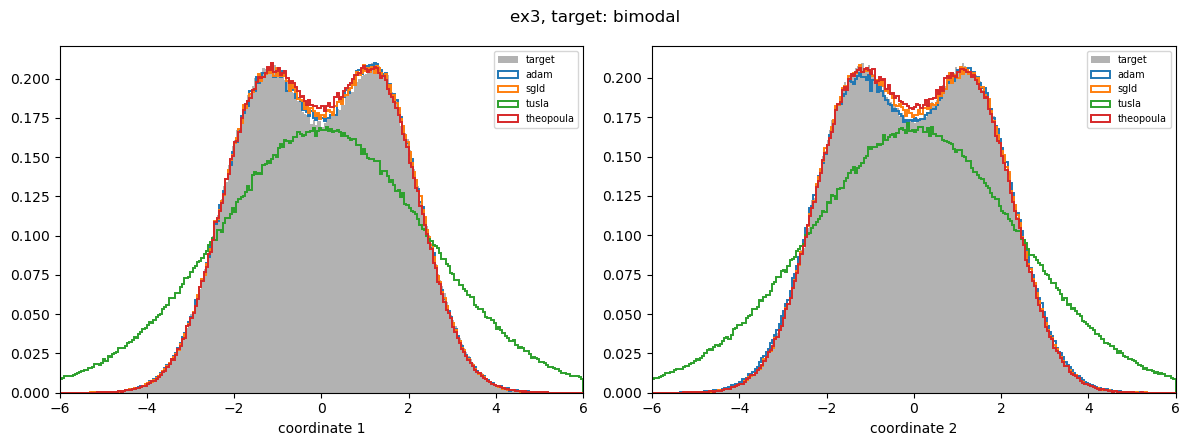

In [25]:
# Unimodel plot
# Marginals for every example: ex1 (Gaussian, affine), ex2 (Gaussian, network),
# ex3 (mixture, network). One figure per example, same construction as before.

EXAMPLES_H = [
    # (example, target, x-axis window)
    ("ex1", "gaussian", (-3.0, 6.0)),
    ("ex2", "gaussian", (-3.0, 6.0)),
    ("ex3", "bimodal",  (-6.0, 6.0)),
]
N_TRUE = 1_000_000       # target reference draws
N_BINS = 240

for EXAMPLE_H, TARGET_H, (LO, HI) in EXAMPLES_H:
    BINS = np.linspace(LO, HI, N_BINS + 1)

    target = fct.make_target(TARGET_H, 2, MU, 1.0)
    np.random.seed(0)
    true = target["sample"](N_TRUE)

    opts_avail = [o for o in ["adam", "sgld", "tusla", "theopoula"]
                  if any(r_["config"]["example"] == EXAMPLE_H
                         and r_["config"]["optimiser"] == o
                         and "plot_samples" in r_ for r_ in main_runs.values())]
    if not opts_avail:
        print(f"no plot_samples for {EXAMPLE_H}")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for k in range(2):
        axes[k].hist(true[:, k], bins=BINS, density=True, alpha=0.3,
                     color="k", label="target")
        for opt in opts_avail:
            rec = next(r_ for r_ in main_runs.values()
                       if r_["config"]["example"] == EXAMPLE_H
                       and r_["config"]["optimiser"] == opt
                       and "plot_samples" in r_)
            s = rec["plot_samples"]
            frac = float(np.mean((s >= LO).all(1) & (s <= HI).all(1)))
            axes[k].hist(s[:, k], bins=BINS, density=True, histtype="step",
                         lw=1.4, label=f"{opt}")
        axes[k].set_xlim(LO, HI)
        axes[k].set_xlabel(f"coordinate {k + 1}")
        axes[k].legend(fontsize=7)
    plt.suptitle(f"{EXAMPLE_H}, target: {TARGET_H}")
    plt.tight_layout()
    savefig(f"marginals_{EXAMPLE_H}")

## Cell 7 — E3: marginal histograms and scatter (fig:e3_samples)

Histograms use the stored 1,000,000 generated samples per optimiser (seed 0,
generated after the full 50,000 iterations, fresh seed `eval_seed+777`),
against 1,000,000 fresh target draws. 240 bins on $[-6, 6]$.

Caveat: `density=True` normalises over the mass INSIDE the window, so the
legend reports the fraction of samples in-window; read the two together.
Scatter panels subsample 5,000 of the 1M points for legibility and show the
mode balance (fraction of mass in the $+\bar\mu$ mode; 0.5 is perfect).

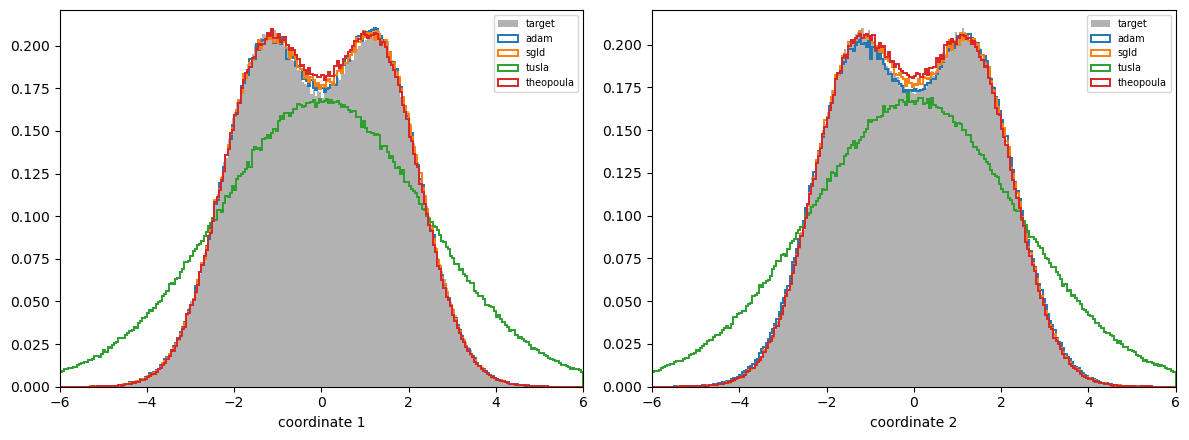

In [14]:
EXAMPLE_H = "ex3"        # <-- example to plot
TARGET_H = "bimodal"     # <-- its target
LIM = 6.0                # axis limit, both plots
BINS = np.linspace(-LIM, LIM, 241)
N_TRUE = 1_000_000       # target reference draws
N_SCATTER = 5_000        # points shown per scatter panel

target = fct.make_target(TARGET_H, 2, MU, 1.0)
np.random.seed(0)
true = target["sample"](N_TRUE)

opts_avail = [o for o in ["adam", "sgld", "tusla", "theopoula"]
              if any(r_["config"]["example"] == EXAMPLE_H
                     and r_["config"]["optimiser"] == o
                     and "plot_samples" in r_ for r_ in main_runs.values())]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for k in range(2):
    axes[k].hist(true[:, k], bins=BINS, density=True, alpha=0.3, color="k",
                 label="target")
    for opt in opts_avail:
        rec = next(r_ for r_ in main_runs.values()
                   if r_["config"]["example"] == EXAMPLE_H
                   and r_["config"]["optimiser"] == opt
                   and "plot_samples" in r_)
        s = rec["plot_samples"]
        frac = float(np.mean(np.all(np.abs(s) <= LIM, axis=1)))
        axes[k].hist(s[:, k], bins=BINS, density=True, histtype="step",
                     lw=1.4, label=f"{opt}")
    axes[k].set_xlim(-LIM, LIM)
    axes[k].set_xlabel(f"coordinate {k + 1}")
    axes[k].legend(fontsize=7)
plt.tight_layout()
savefig(f"e3_marginals_{EXAMPLE_H}")




generating 200,000 samples for depth_L12_adam (L=11, T=2.0)
    saved outputs5/depth_plot_samples.pt
generating 200,000 samples for depth_L12_theopoula (L=11, T=2.0)
    saved outputs5/depth_plot_samples.pt
generating 200,000 samples for depth_L16_adam (L=15, T=2.0)
    saved outputs5/depth_plot_samples.pt
generating 200,000 samples for depth_L16_theopoula (L=15, T=2.0)
    saved outputs5/depth_plot_samples.pt
generating 200,000 samples for depth_L20_adam (L=19, T=2.0)
    saved outputs5/depth_plot_samples.pt
generating 200,000 samples for depth_L20_theopoula (L=19, T=2.0)
    saved outputs5/depth_plot_samples.pt
generating 200,000 samples for depth_L2_adam (L=1, T=2.0)
    saved outputs5/depth_plot_samples.pt
generating 200,000 samples for depth_L2_theopoula (L=1, T=2.0)
    saved outputs5/depth_plot_samples.pt
generating 200,000 samples for depth_L4_adam (L=3, T=2.0)
    saved outputs5/depth_plot_samples.pt
generating 200,000 samples for depth_L4_theopoula (L=3, T=2.0)
    saved outp

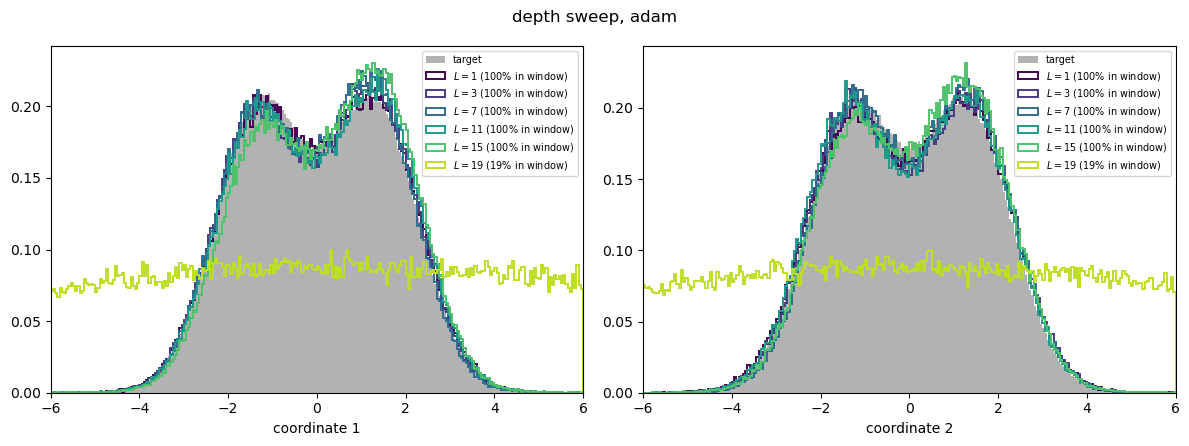

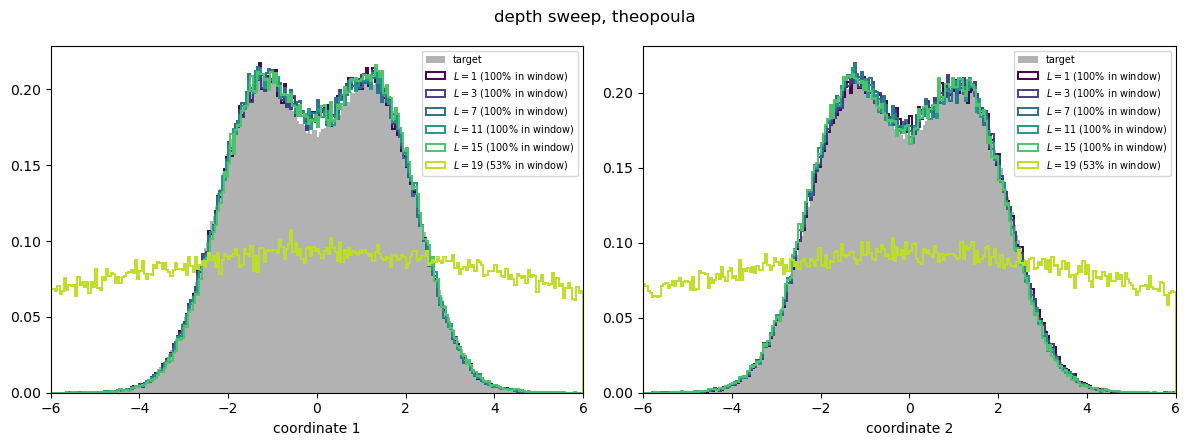

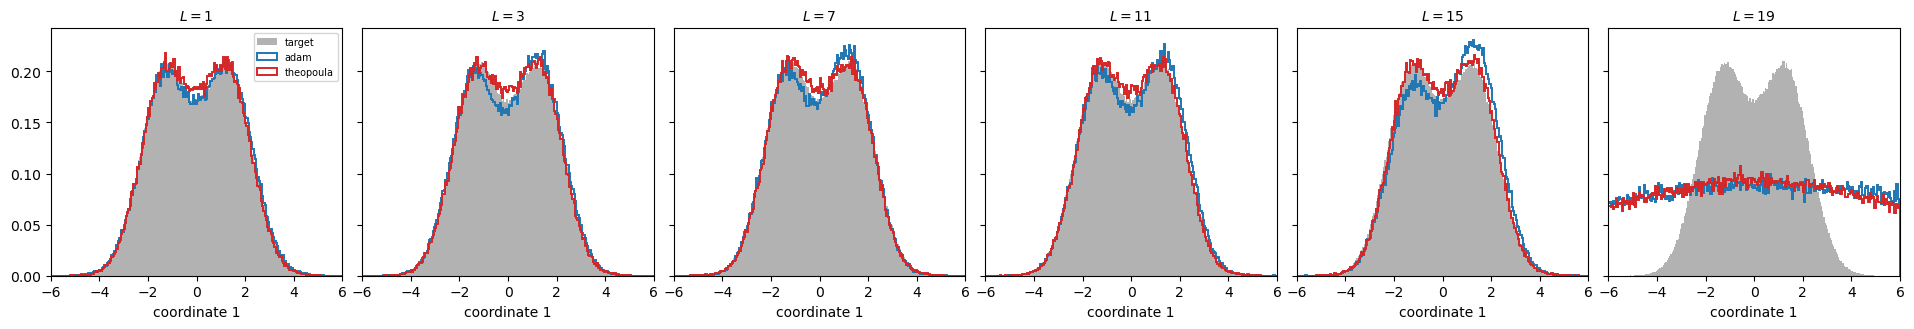

In [ ]:
# Cell 7.1

# %% [markdown]
# ## Depth marginals — regenerate samples from the saved depth-sweep networks
#
# `stage_depth` ran with `keep_plot_samples=False`, so no depth record holds
# `plot_samples`. Every record does hold `net_state`, so the samples can be
# regenerated without retraining. Cell A does the generation once and caches
# it to disk; Cell B plots. Re-running Cell B is free.

# %% Cell A: regenerate samples from net_state (slow, cached)
import os
import numpy as np
import torch

import functions5 as fct

# --- must match run_experiment5.py ---
D          = 2
MU         = np.array([1.3, 1.3])
SIGMA_0    = 1.0
WIDTH      = 128
USE_SKIP   = False
GAMMA      = 1e-3
EVAL_SEED  = 9_000

N_PLOT_DEPTH = 200_000     # 240 bins -> ~800 counts/bin; raise to 1e6 if patient
EM_BATCH     = 50_000
CACHE = os.path.join(OUT_DIR, "depth_plot_samples.pt")

device = fct.get_device()

if os.path.exists(CACHE):
    depth_samples = fct.load_results(CACHE)
    print(f"loaded cached samples for {len(depth_samples)} runs")
else:
    depth_samples = {}

for tag, rec in sorted(depth_runs.items()):
    if tag in depth_samples:
        continue
    c = rec["config"]
    if rec.get("diverged"):
        print(f"skip {tag}: diverged at iteration {rec.get('nan_iter')}")
        continue

    net = fct.build_net(D, c["arch"], WIDTH, USE_SKIP)
    net.load_state_dict(rec["net_state"])
    net.to(device).eval()

    if not all(torch.isfinite(p).all() for p in net.parameters()):
        print(f"skip {tag}: non-finite parameters in net_state")
        continue

    print(f"generating {N_PLOT_DEPTH:,} samples for {tag} "
          f"(L={c['arch'] - 1}, T={c['T']})")
    fct.set_seed(EVAL_SEED + 777)          # common random numbers across runs
    s = fct.em_sample(net, GAMMA, c["T"], D, N_PLOT_DEPTH, device,
                      batch=EM_BATCH).astype(np.float32)

    depth_samples[tag] = dict(
        samples=s,
        L=c["arch"] - 1,
        optimiser=c["optimiser"],
        mode_balance=fct.mode_balance(s, MU),
        frac_finite=float(np.mean(np.all(np.isfinite(s), axis=1))))
    fct.save_results(depth_samples, CACHE)

print("\navailable:")
for tag, d_ in sorted(depth_samples.items(), key=lambda kv: kv[1]["L"]):
    print(f"  {tag:28s} L={d_['L']:2d}  balance={d_['mode_balance']:.4f}  "
          f"finite={d_['frac_finite']:.1%}")


# %% Cell B: marginals by depth, one figure per optimiser
import matplotlib.pyplot as plt

TARGET_H = "bimodal"
LIM  = 6.0
BINS = np.linspace(-LIM, LIM, 241)
N_TRUE = 1_000_000

target = fct.make_target(TARGET_H, D, MU, SIGMA_0)
np.random.seed(0)
true = target["sample"](N_TRUE)

for opt in ["adam", "theopoula"]:
    runs_o = sorted([d_ for d_ in depth_samples.values()
                     if d_["optimiser"] == opt],
                    key=lambda d_: d_["L"])
    if not runs_o:
        print(f"no samples for {opt}")
        continue

    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(runs_o)))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for k in range(2):
        axes[k].hist(true[:, k], bins=BINS, density=True, alpha=0.3,
                     color="k", label="target")
        for col, d_ in zip(cmap, runs_o):
            s = d_["samples"]
            frac = float(np.mean(np.all(np.abs(s) <= LIM, axis=1)))
            axes[k].hist(s[:, k], bins=BINS, density=True, histtype="step",
                         lw=1.4, color=col,
                         label=f"$L={d_['L']}$ ")
        axes[k].set_xlim(-LIM, LIM)
        axes[k].set_xlabel(f"coordinate {k + 1}")
        axes[k].legend(fontsize=7)
    plt.suptitle(f"depth sweep, {opt}")
    plt.tight_layout()
    savefig(f"e3_marginals_depth_{opt}")




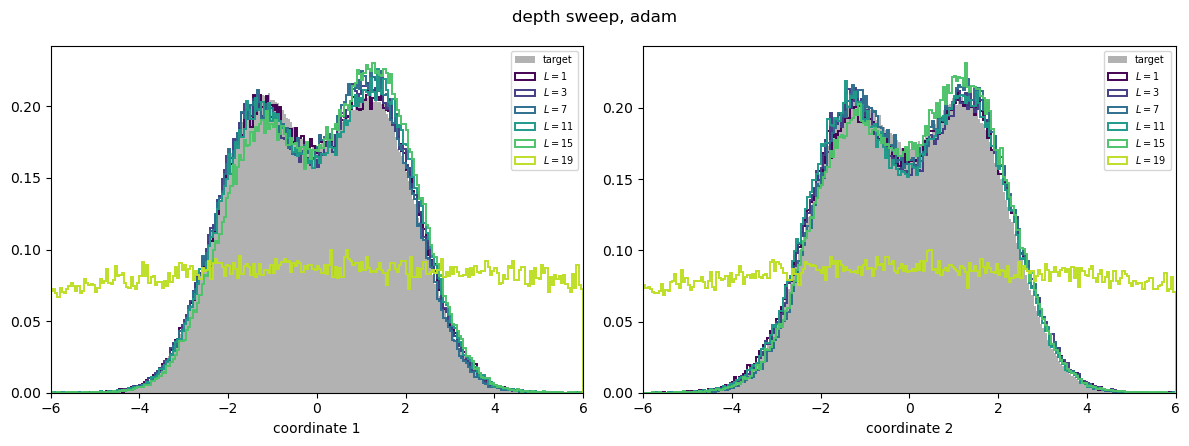

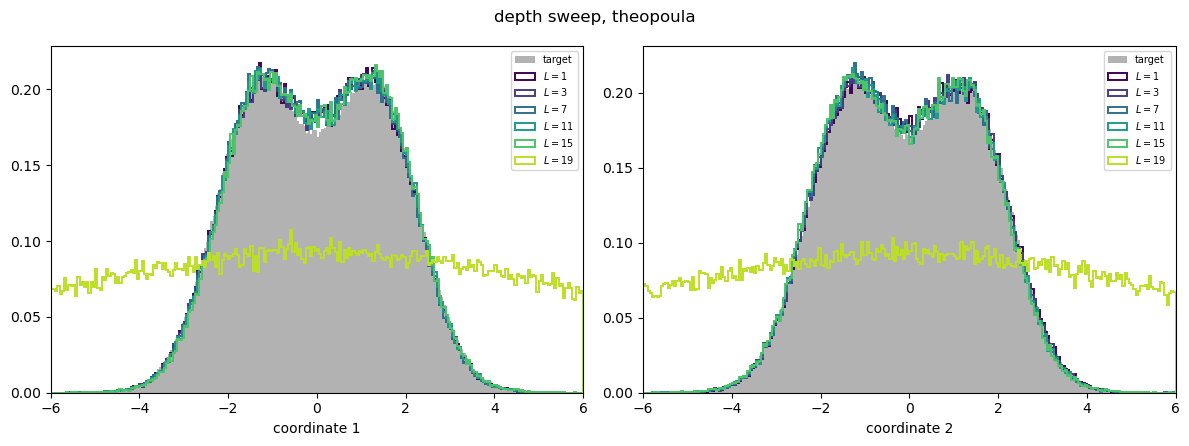

In [17]:
# %% Cell B: marginals by depth, one figure per optimiser
import matplotlib.pyplot as plt

TARGET_H = "bimodal"
LIM  = 6.0
BINS = np.linspace(-LIM, LIM, 241)
N_TRUE = 1_000_000

target = fct.make_target(TARGET_H, D, MU, SIGMA_0)
np.random.seed(0)
true = target["sample"](N_TRUE)

for opt in ["adam", "theopoula"]:
    runs_o = sorted([d_ for d_ in depth_samples.values()
                     if d_["optimiser"] == opt],
                    key=lambda d_: d_["L"])
    if not runs_o:
        print(f"no samples for {opt}")
        continue

    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(runs_o)))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for k in range(2):
        axes[k].hist(true[:, k], bins=BINS, density=True, alpha=0.3,
                     color="k", label="target")
        for col, d_ in zip(cmap, runs_o):
            s = d_["samples"]
            frac = float(np.mean(np.all(np.abs(s) <= LIM, axis=1)))
            axes[k].hist(s[:, k], bins=BINS, density=True, histtype="step",
                         lw=1.4, color=col,
                         label=f"$L={d_['L']}$ ")
        axes[k].set_xlim(-LIM, LIM)
        axes[k].set_xlabel(f"coordinate {k + 1}")
        axes[k].legend(fontsize=7)
    plt.suptitle(f"depth sweep, {opt}")
    plt.tight_layout()
    savefig(f"e3_marginals_depth_{opt}")

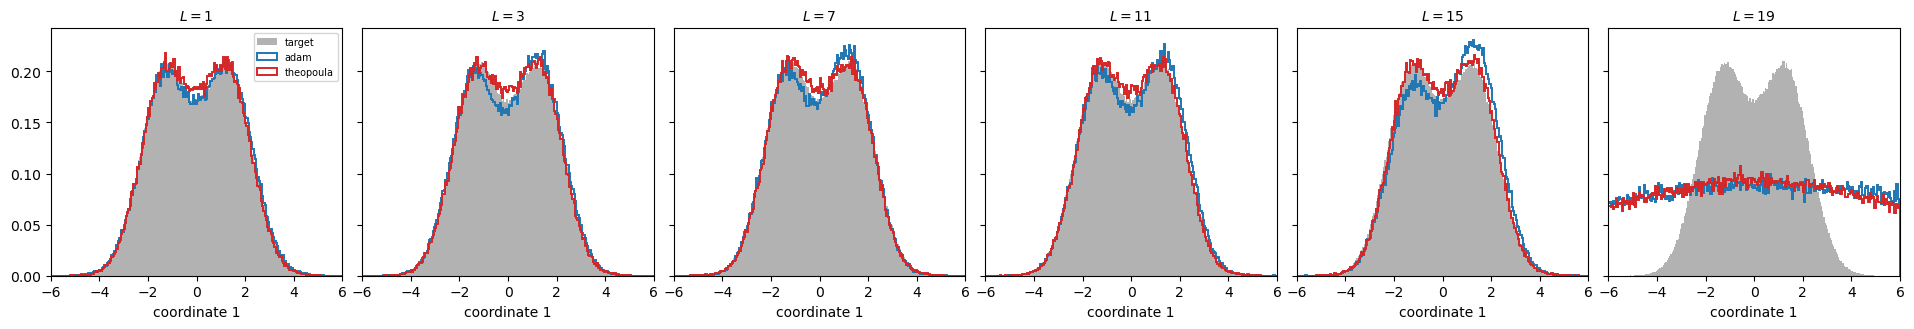

In [ ]:
# %% Cell C: side-by-side at fixed depth, both optimisers (optional)
# One panel per L, coordinate 1 only. Makes the adam-vs-theopoula
# divergence with depth immediately visible.
Ls = sorted({d_["L"] for d_ in depth_samples.values()})
fig, axes = plt.subplots(1, len(Ls), figsize=(3.2 * len(Ls), 3.4),
                         sharey=True)
axes = np.atleast_1d(axes)
for ax, L in zip(axes, Ls):
    ax.hist(true[:, 0], bins=BINS, density=True, alpha=0.3, color="k",
            label="target")
    for opt, col in [("adam", "C0"), ("theopoula", "C3")]:
        d_ = next((v for v in depth_samples.values()
                   if v["L"] == L and v["optimiser"] == opt), None)
        if d_ is None:
            continue
        ax.hist(d_["samples"][:, 0], bins=BINS, density=True,
                histtype="step", lw=1.4, color=col, label=opt)
    ax.set_xlim(-LIM, LIM)
    ax.set_title(f"$L={L}$", fontsize=10)
    ax.set_xlabel("coordinate 1")
axes[0].legend(fontsize=7)
plt.tight_layout()
savefig("e3_marginals_depth_grid")



## Cell 8 — E2: terminal time sweep against $t^\star$ (fig:e2_terminal_time)

Each point is a network trained AFRESH at its own $T$ (50,000 iterations, best
grid hyperparameters), so train and test noise levels always match. Shaded
band: the interval of thresholds $t^\star(K, \mu(R))$ from Prop.
beta_integral with $K = |\bar\mu|^2 - 1 = 2.38$ and $\mu(R) = 1 - 2|\bar\mu|/R$
over $R \in [5, 100]$. Below $t^\star$, increasing $T$ cannot suppress the
initialisation error. Right panel: score error is roughly flat in $T$, so the
$T$-dependence on the left is attributable to the initialisation term.

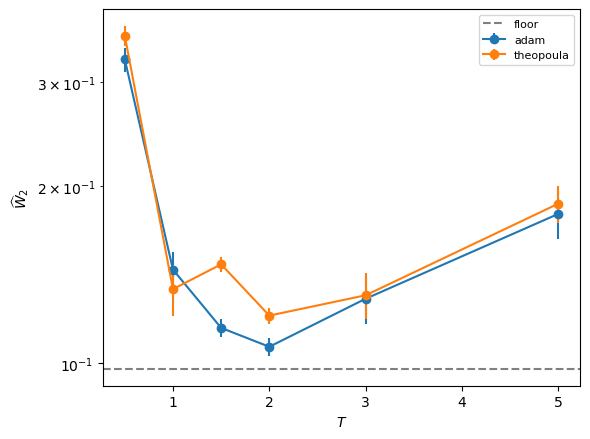

,K,R,mu,lower_bound,t_star
0,2.38,5.0,0.2646,1.7775,5.6617
1,2.38,10.0,0.6323,0.9696,2.5884
2,2.38,20.0,0.8162,0.7601,2.0152
3,2.38,50.0,0.9265,0.6639,1.7652
4,2.38,100.0,0.9632,0.6356,1.6926


In [20]:
K = fct.K_bimodal(MU)                       # 2.38
t_star_lim = fct.t_star(K, fct.mu_of_R(MU, 1e4))   # R -> inf, mu -> 1: t* -> 1.62

# tab:t_star as a DataFrame
tstar_rows = []
for R in [5.0, 10.0, 20.0, 50.0, 100.0]:
    m = fct.mu_of_R(MU, R)
    if m > 0:
        tstar_rows.append(dict(K=K, R=R, mu=m,
                               lower_bound=float(np.log(np.sqrt(1 + K / m**2))),
                               t_star=fct.t_star(K, m)))
tstar_df = pd.DataFrame(tstar_rows)

fig, ax = plt.subplots(figsize=(6, 4.5))
for opt in ["adam", "theopoula"]:
    recs = sorted([r_ for r_ in tsweep_runs.values()
                   if r_["config"]["optimiser"] == opt and "w2_mean" in r_],
                  key=lambda r_: r_["config"]["T"])
    Ts = [r_["config"]["T"] for r_ in recs]
    ax.errorbar(Ts, [r_["w2_mean"] for r_ in recs],
                yerr=[r_["w2_std"] for r_ in recs], marker="o",
                label=opt)
ax.axhline(floors["bimodal"]["mean"], color="grey", ls="--",
           label="floor")

ax.set_xlabel("$T$"); ax.set_ylabel(r"$\widehat W_2$")
ax.set_yscale("log"); ax.legend(fontsize=8)
plt.tight_layout()
savefig("e2_terminal_time")

tstar_df

## Cell 9 — E4: depth (tab:depth_sweep_results, fig e4_depth)

Depth ladder at fixed width 128, 50,000 iterations, best grid hyperparameters,
bimodal target, seed 0. $q = 2L+1$; TheoPouLa needs $r \ge q/2$, TUSLA
$r \ge q/2 + 1$; $r = 10$ is used at EVERY depth, so admissibility is crossed
by design at $L = 10$. `grad_ratio` = largest/smallest layerwise weight
gradient norm at initialisation (the vanishing-gradient mechanism).

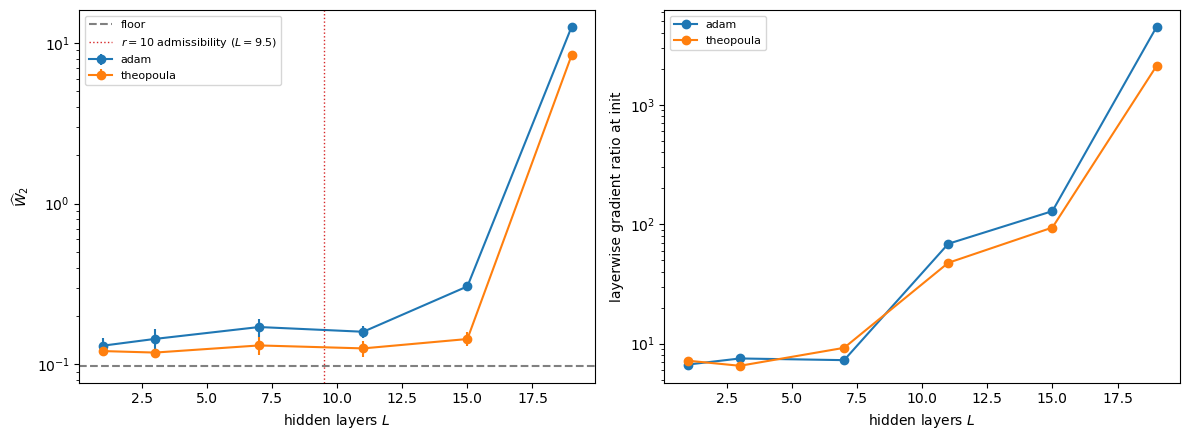

,optimiser,L,q,r_min_theo,r_used,admissible,grad_ratio,W2,sd,Ebar,diverged
0,adam,1,3.0,1.5,10.0,None,6.6851,0.1307,0.0143,0.0045,False
1,adam,3,7.0,3.5,10.0,None,7.5172,0.1440,0.0215,0.0086,False
2,adam,7,15.0,7.5,10.0,None,7.2767,0.1707,0.0218,0.0096,False
3,adam,11,23.0,11.5,10.0,None,68.6692,0.1595,0.0128,0.0080,False
4,adam,15,31.0,15.5,10.0,None,128.9376,0.3056,0.0201,0.0112,False
5,adam,19,39.0,19.5,10.0,None,4500.9610,12.5699,0.0038,1.6585,False
6,theopoula,1,3.0,1.5,10.0,True,7.1988,0.1210,0.0053,0.0161,False
7,theopoula,3,7.0,3.5,10.0,True,6.5277,0.1184,0.0059,0.0111,False
8,theopoula,7,15.0,7.5,10.0,True,9.2295,0.1311,0.0165,0.0141,False
9,theopoula,11,23.0,11.5,10.0,False,47.5684,0.1257,0.0142,0.0123,False


In [9]:
rows = []
for tag, rec in sorted(depth_runs.items(),
                       key=lambda kv: (kv[1]["config"]["optimiser"],
                                       kv[1]["config"]["arch"])):
    c = rec["config"]
    rows.append(dict(
        optimiser=c["optimiser"], L=c["arch"] - 1, q=fct.q_of(c["arch"]),
        r_min_theo=fct.r_min(c["arch"]), r_used=rec.get("r_used"),
        admissible=rec.get("r_admissible"), grad_ratio=rec.get("grad_ratio"),
        W2=rec.get("w2_mean"), sd=rec.get("w2_std"),
        Ebar=rec.get("score_error_agg"), diverged=rec["diverged"]))
depth_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for opt, sub in depth_df.groupby("optimiser"):
    sub = sub.sort_values("L")
    axes[0].errorbar(sub["L"], sub["W2"], yerr=sub["sd"], marker="o",
                     label=opt)
    axes[1].plot(sub["L"], sub["grad_ratio"], marker="o", label=opt)
axes[0].axhline(floors["bimodal"]["mean"], color="grey", ls="--",
                label="floor")
axes[0].axvline(9.5, color="C3", ls=":", lw=1,
                label="$r=10$ admissibility ($L=9.5$)")
axes[0].set_xlabel("hidden layers $L$"); axes[0].set_ylabel(r"$\widehat W_2$")
axes[0].set_yscale("log"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("hidden layers $L$")
axes[1].set_ylabel("layerwise gradient ratio at init")
axes[1].set_yscale("log"); axes[1].legend(fontsize=8)
plt.tight_layout()
savefig("e4_depth")

depth_df


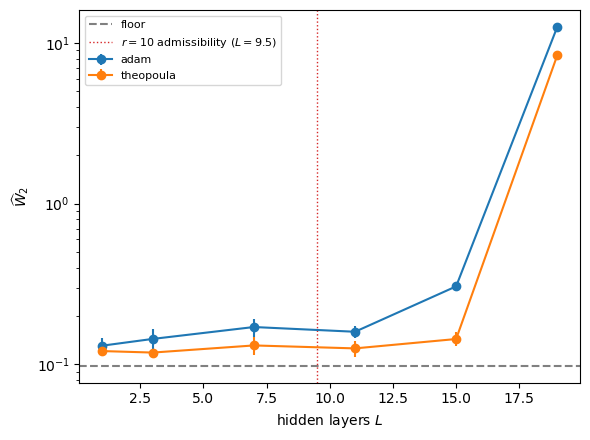

,optimiser,L,q,r_min_theo,r_used,admissible,grad_ratio,W2,sd,Ebar,diverged
0,adam,1,3.0,1.5,10.0,None,6.6851,0.1307,0.0143,0.0045,False
1,adam,3,7.0,3.5,10.0,None,7.5172,0.1440,0.0215,0.0086,False
2,adam,7,15.0,7.5,10.0,None,7.2767,0.1707,0.0218,0.0096,False
3,adam,11,23.0,11.5,10.0,None,68.6692,0.1595,0.0128,0.0080,False
4,adam,15,31.0,15.5,10.0,None,128.9376,0.3056,0.0201,0.0112,False
5,adam,19,39.0,19.5,10.0,None,4500.9610,12.5699,0.0038,1.6585,False
6,theopoula,1,3.0,1.5,10.0,True,7.1988,0.1210,0.0053,0.0161,False
7,theopoula,3,7.0,3.5,10.0,True,6.5277,0.1184,0.0059,0.0111,False
8,theopoula,7,15.0,7.5,10.0,True,9.2295,0.1311,0.0165,0.0141,False
9,theopoula,11,23.0,11.5,10.0,False,47.5684,0.1257,0.0142,0.0123,False


In [22]:
rows = []
for tag, rec in sorted(depth_runs.items(),
                       key=lambda kv: (kv[1]["config"]["optimiser"],
                                       kv[1]["config"]["arch"])):
    c = rec["config"]
    rows.append(dict(
        optimiser=c["optimiser"], L=c["arch"] - 1, q=fct.q_of(c["arch"]),
        r_min_theo=fct.r_min(c["arch"]), r_used=rec.get("r_used"),
        admissible=rec.get("r_admissible"), grad_ratio=rec.get("grad_ratio"),
        W2=rec.get("w2_mean"), sd=rec.get("w2_std"),
        Ebar=rec.get("score_error_agg"), diverged=rec["diverged"]))
depth_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6, 4.5))
for opt, sub in depth_df.groupby("optimiser"):
    sub = sub.sort_values("L")
    ax.errorbar(sub["L"], sub["W2"], yerr=sub["sd"], marker="o", label=opt)

ax.axhline(floors["bimodal"]["mean"], color="grey", ls="--", label="floor")
ax.axvline(9.5, color="C3", ls=":", lw=1, label="$r=10$ admissibility ($L=9.5$)")
ax.set_xlabel("hidden layers $L$")
ax.set_ylabel(r"$\widehat W_2$")
ax.set_yscale("log")
ax.legend(fontsize=8)

plt.tight_layout()
savefig("e4_depth")

depth_df

## Cell 10 — Example 1: the observable $\widetilde\varepsilon_{AL}$

For the affine approximator $\theta^* = \mu_\star$ is KNOWN, so
$|\hat\theta - \mu_\star|^2$ is directly observable — the only configuration
where Assumption 1 can be checked rather than hypothesised. `lam_max_sgld` is
the step restriction eq:ex1_lambda; SGLD's theory covers it only if
`lam used` $\le$ `lam_max_sgld`.

In [10]:
rows = []
for tag, rec in sorted(main_runs.items()):
    c = rec["config"]
    if c["example"] != "ex1" or "eps_AL_observed" not in rec:
        continue
    rows.append(dict(optimiser=c["optimiser"], seed=c["seed"],
                     eps_AL=rec["eps_AL_observed"],
                     theta_hat=np.round(rec["theta_hat"], 4),
                     W2=rec["w2_mean"], lam_used=c["params"]["lam"],
                     lam_max_sgld=rec["sgld_lambda_max"]))
ex1_df = pd.DataFrame(rows)
ex1_df


,optimiser,seed,eps_AL,theta_hat,W2,lam_used,lam_max_sgld
0,adam,0,5.1622e-05,"[1.2947, 1.2951]",0.0903,0.001,1.4484
1,adam,1,5.4793e-05,"[1.3072, 1.2981]",0.0856,0.001,1.4484
2,adam,2,8.0737e-05,"[1.2972, 1.2915]",0.0907,0.001,1.4484
3,sgld,0,1.2672e-05,"[1.3035, 1.2997]",0.0861,0.010,1.4484
4,sgld,1,1.8870e-05,"[1.3043, 1.3003]",0.0857,0.010,1.4484
5,sgld,2,1.2672e-05,"[1.3035, 1.2997]",0.0861,0.010,1.4484
6,theopoula,0,1.4466e-05,"[1.3006, 1.2962]",0.0880,0.010,1.4484
7,theopoula,1,2.0081e-05,"[1.3037, 1.2974]",0.0868,0.010,1.4484
8,theopoula,2,1.4466e-05,"[1.3006, 1.2962]",0.0880,0.010,1.4484
9,tusla,0,2.8790e-01,"[0.9217, 0.9195]",0.5705,1.000,1.4484


## Cell 11 — loss and $|\theta|$ trajectories (diagnostic)

Full per-iteration histories for one run. Not a paper figure by default;
used to verify stability (no drift in $|\theta|$, loss at its floor).

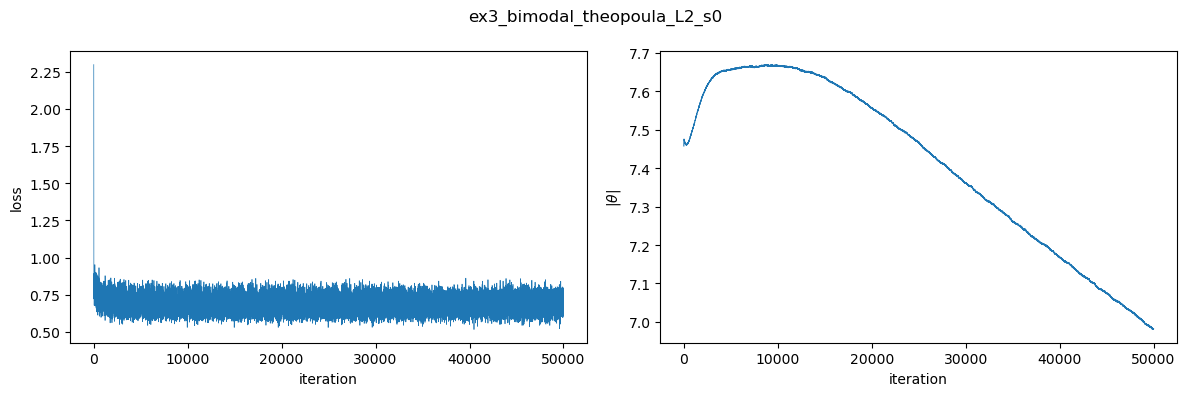

In [11]:
TAG = "ex3_bimodal_theopoula_L2_s0"    # <-- any key of main_runs
if TAG in main_runs:
    rec = main_runs[TAG]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(rec["loss_history"], lw=0.5)
    axes[0].set_xlabel("iteration"); axes[0].set_ylabel("loss")
    axes[1].plot(rec["theta_norm_history"], lw=0.8)
    axes[1].set_xlabel("iteration"); axes[1].set_ylabel(r"$|\theta|$")
    plt.suptitle(TAG)
    plt.tight_layout()
    savefig(f"trajectories_{TAG}")
else:
    print("available:", sorted(main_runs)[:10])


## Cell 12 — raw vs applied layerwise gradient norms (mechanism figure)

At the final gradient checkpoint of one run: the RAW gradient norm per weight
matrix (before taming/boosting/preconditioning) against the norm of the update
actually applied. At depth the raw gradient vanishes toward the input side;
Adam's preconditioner and TheoPouLa's boosting flatten the applied update,
SGLD and TUSLA do not.

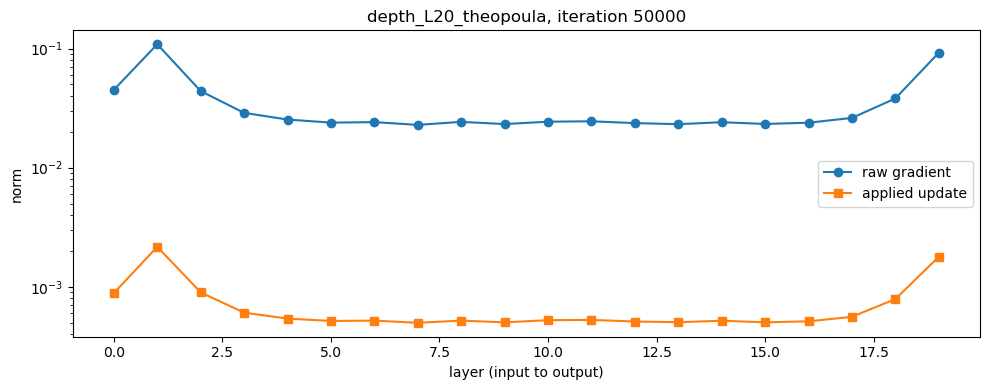

In [12]:
TAG_G = "depth_L20_theopoula"          # <-- any run with grad checkpoints
rec = depth_runs.get(TAG_G) or main_runs.get(TAG_G)
if rec and rec["grad_norms"]:
    it = max(rec["grad_norms"])        # last checkpoint (= final iteration)
    names = [n for n in rec["grad_norms"][it] if "weight" in n]
    raw = [rec["grad_norms"][it][n] for n in names]
    upd = [rec["update_norms"][it][n] for n in names]
    x = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(x, raw, "o-", label="raw gradient")
    ax.semilogy(x, upd, "s-", label="applied update")
    ax.set_xlabel("layer (input to output)")
    ax.set_ylabel("norm")
    ax.set_title(f"{TAG_G}, iteration {it}")
    ax.legend()
    plt.tight_layout()
    savefig(f"grad_profile_{TAG_G}")
else:
    print("available:", sorted(depth_runs))


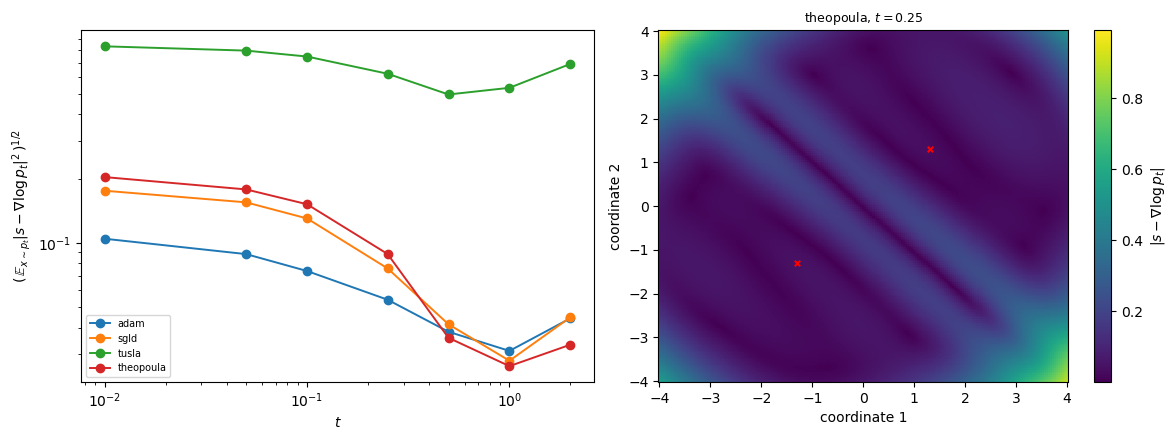

In [21]:
# ============================================================
# Score accuracy figure: |s(theta_hat, x, t) - grad log p_t(x)|
# against the closed-form marginal score (eq:marginal_score_tanh),
# from the saved nets in main_runs. No retraining.
# ============================================================
import torch

EXAMPLE_H   = "ex3"          # ex2 also works (Gaussian target, network)
TARGET_H    = "bimodal"
TS_CURVE    = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]   # = SCORE_TS
T_HEAT      = 0.25           # representative t for the spatial panel
OPT_HEAT    = "theopoula"    # net shown in the heatmap
LIM, NG     = 4.0, 201       # heatmap window and grid resolution
N_MC        = 20_000         # x_t ~ p_t draws per t for panel (a)
SEED_PLOT   = 0

device = fct.get_device()
target = fct.make_target(TARGET_H, 2, MU, SIGMA_0)

def marginal_score(x, t):
    """Closed form, sigma_0 = 1 so v_t = 1 (eq:marginal_score_tanh)."""
    m = np.exp(-t)
    return -x + m * np.tanh(m * (x @ MU))[:, None] * MU[None, :]

def net_from(rec):
    net = fct.build_net(D, rec["config"]["arch"], rec["config"]["width"],
                        rec["config"]["use_skip"]).to(device)
    net.load_state_dict(rec["net_state"])
    net.eval()
    return net

def net_score(net, x, t):
    with torch.no_grad():
        xt = torch.as_tensor(x, dtype=torch.float32, device=device)
        tt = torch.full((len(x), 1), t, dtype=torch.float32, device=device)
        return net(xt, tt).cpu().numpy()      # adjust if forward signature differs

def rms_err(net, t, rng):
    """sqrt( E_{x_t ~ p_t} |s - grad log p_t|^2 ), the eps_SN integrand."""
    x0 = target["sample"](N_MC)
    z  = rng.standard_normal((N_MC, D))
    xt = np.exp(-t) * x0 + np.sqrt(1 - np.exp(-2 * t)) * z
    d  = net_score(net, xt, t) - marginal_score(xt, t)
    return float(np.sqrt(np.mean(np.sum(d ** 2, axis=1))))

recs = {o: r_ for o in ["adam", "sgld", "tusla", "theopoula"]
        for r_ in main_runs.values()
        if r_["config"]["example"] == EXAMPLE_H
        and r_["config"]["optimiser"] == o
        and r_["config"]["seed"] == SEED_PLOT
        and not r_.get("diverged", False)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- panel (a): RMS error vs t ------------------------------------------
rng = np.random.default_rng(EVAL_SEED)
for opt, rec in recs.items():
    net = net_from(rec)
    errs = [rms_err(net, t, rng) for t in TS_CURVE]
    axes[0].plot(TS_CURVE, errs, marker="o", lw=1.4, label=opt)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$(\,\mathbb{E}_{x\sim p_t}|s-\nabla\log p_t|^2\,)^{1/2}$")
axes[0].legend(fontsize=7)

# --- panel (b): pointwise error heatmap at T_HEAT -----------------------
g  = np.linspace(-LIM, LIM, NG)
xx, yy = np.meshgrid(g, g)
grid = np.column_stack([xx.ravel(), yy.ravel()])
net  = net_from(recs[OPT_HEAT])
err  = np.linalg.norm(net_score(net, grid, T_HEAT)
                      - marginal_score(grid, T_HEAT), axis=1).reshape(NG, NG)
im = axes[1].pcolormesh(g, g, err, shading="auto")
fig.colorbar(im, ax=axes[1], label=r"$|s-\nabla\log p_t|$")
axes[1].scatter([MU[0], -MU[0]], [MU[1], -MU[1]], c="r", s=15, marker="x")
axes[1].set_xlabel("coordinate 1"); axes[1].set_ylabel("coordinate 2")
axes[1].set_title(f"{OPT_HEAT}, $t={T_HEAT}$", fontsize=9)

plt.tight_layout()
savefig(f"score_accuracy_{EXAMPLE_H}")